In [1]:
# =============================================================================
# TCC — Caracterização Não Supervisionada de Perturbações Elétricas
# Rafael Benzaquem Neto | UFRR — ECAI 4.0
#
# MÓDULO 2 — Autoencoder Convolucional (CAE) — Seção 4.3.2
# Entrada : X_cae_input.npy  shape (N, 384, 3)  — saída do Módulo 1
# Saída   : vetores latentes  shape (N, LATENT_DIM)  → entrada do K-Means
# =============================================================================
# Compatível com Google Colab. Execute célula a célula (▶).
# GPU recomendada: Ambiente de execução → Alterar tipo de ambiente → T4 GPU
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# ─────────────────────────────────────────────────────────────────────────────
#!pip install tensorflow scikit-learn matplotlib numpy --quiet

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.optimizers import Adam

# Scikit-learn — métricas de reconstrução
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
#from google.colab import drive

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Bibliotecas carregadas com sucesso.")
print(f"   TensorFlow: {tf.__version__}")
print(f"   GPU disponível: {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1775365617.546402  199782 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Bibliotecas carregadas com sucesso.
   TensorFlow: 2.21.0
   GPU disponível: True


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configurações globais do CAE
#            Todos os hiperparâmetros estão centralizados aqui.
#            Altere neste bloco antes de rodar o pipeline.
# ─────────────────────────────────────────────────────────────────────────────

# Diretório de dados — adapte ao caminho no Colab/Drive
#drive.mount('/content/drive')

# ---------- Caminhos ----------
# Arquivo de entrada gerado pelo Módulo 1
INPUT_NPY   = './1_dados_preprocessados_v2/X_cae_input.npy'

# Diretório de saída deste módulo
OUTPUT_DIR  = './2_dados_cae_v2'

# ---------- Arquitetura do CAE ----------
# Dimensão do vetor latente (bottleneck).
# Valores menores forçam maior compressão; testar 8, 16, 32.
# Islam et al. (2023) utilizam espaço latente compacto para boa separabilidade.
LATENT_DIM  = 16

# Filtros em cada bloco Conv1D do Encoder (ordem crescente)
# Decoder usa a ordem inversa automaticamente.
FILTERS     = [32, 64, 128]

# Tamanho dos kernels Conv1D (blocos 1, 2 e 3)
KERNEL_SIZES = [5, 5, 3]

# Fator de redução por MaxPooling (encoder) / UpSampling (decoder)
POOL_SIZE   = 2

# ---------- Treinamento ----------
EPOCHS      = 100         # Número máximo de épocas
BATCH_SIZE  = 16          # Tamanho do mini-batch (ajuste para GPU: 32 ou 64)
LEARNING_RATE = 1e-3      # Taxa de aprendizado inicial do Adam
VAL_SPLIT   = 0.15        # Fração de validação (15 %)
PATIENCE    = 15          # Early stopping: épocas sem melhora antes de parar

# ---------- Caminhos de saída ----------
MODEL_PATH  = os.path.join(OUTPUT_DIR, 'cae_model.keras')
ENCODER_PATH= os.path.join(OUTPUT_DIR, 'encoder_model.keras')
LATENT_PATH = os.path.join(OUTPUT_DIR, 'Z_latente.npy')
HISTORY_PATH= os.path.join(OUTPUT_DIR, 'historico_treino.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Configurações do CAE carregadas.")
print(f"   Dimensão latente    : {LATENT_DIM}")
print(f"   Filtros encoder     : {FILTERS}")
print(f"   Épocas máx.         : {EPOCHS}  |  Batch: {BATCH_SIZE}")
print(f"   Saída em            : {OUTPUT_DIR}")

✅ Configurações do CAE carregadas.
   Dimensão latente    : 16
   Filtros encoder     : [32, 64, 128]
   Épocas máx.         : 100  |  Batch: 16
   Saída em            : ./2_dados_cae_v2


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Carregamento e validação do tensor de entrada
# ─────────────────────────────────────────────────────────────────────────────

def carregar_tensor_cae(caminho: str) -> np.ndarray:
    """
    Carrega X_cae_input.npy e valida shape e intervalo esperados.

    Retorna
    -------
    np.ndarray float32  shape (N, 384, 3)
    """
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Arquivo não encontrado: '{caminho}'\n"
            "Execute o Módulo 1 (pré-processamento) para gerar X_cae_input.npy."
        )

    X = np.load(caminho).astype(np.float32)

    # Validações de integridade
    assert X.ndim == 3,        f"Shape esperado 3D (N,T,C), obtido {X.ndim}D"
    assert X.shape[2] == 3,    f"Esperado 3 canais (fases), obtido {X.shape[2]}"
    assert np.isfinite(X).all(), "Tensor contém NaN ou Inf — verifique o pré-processamento."

    n, t, c = X.shape
    v_min, v_max = float(X.min()), float(X.max())

    print(f"\n📦 Tensor carregado com sucesso:")
    print(f"   Shape  : {X.shape}  (N_eventos × timesteps × fases)")
    print(f"   Dtype  : {X.dtype}")
    print(f"   Range  : [{v_min:.4f},  {v_max:.4f}] p.u.")
    print(f"   Memória: {X.nbytes / 1024:.1f} KB")

    # Alerta se o range estiver fora de [−2, 2] p.u. (indica erro de normalização)
    if v_max > 2.0 or v_min < -2.0:
        print("   ⚠️  Valores fora de [−2, 2] p.u. — verifique a normalização no Módulo 1.")

    return X


X_input = carregar_tensor_cae(INPUT_NPY)
N_EVENTOS, TIMESTEPS, N_CANAIS = X_input.shape
print(f"\n   N_EVENTOS={N_EVENTOS}  TIMESTEPS={TIMESTEPS}  N_CANAIS={N_CANAIS}")


📦 Tensor carregado com sucesso:
   Shape  : (11928, 384, 3)  (N_eventos × timesteps × fases)
   Dtype  : float32
   Range  : [-2.1199,  1.7635] p.u.
   Memória: 53676.0 KB
   ⚠️  Valores fora de [−2, 2] p.u. — verifique a normalização no Módulo 1.

   N_EVENTOS=11928  TIMESTEPS=384  N_CANAIS=3


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Divisão treino / validação
#
# O CAE é treinado de forma não supervisionada (entrada = saída = X).
# A divisão garante monitoramento honesto do erro de reconstrução.
# Conforme Rodriguez et al. (2020): split 85 / 15 %.
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_val = train_test_split(
    X_input,
    test_size=VAL_SPLIT,
    random_state=42,
    shuffle=True
)

print(f"✅ Divisão treino/validação:")
print(f"   Treino     : {X_train.shape[0]} eventos")
print(f"   Validação  : {X_val.shape[0]} eventos")

✅ Divisão treino/validação:
   Treino     : 10138 eventos
   Validação  : 1790 eventos


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Construção da arquitetura do CAE
#
# Arquitetura conforme Seção 4.3.2 do TCC:
#   Encoder : Conv1D → MaxPooling (×3) → Flatten → Dense (bottleneck)
#   Decoder : Dense → Reshape → UpSampling → Conv1D (×3) → Conv1D saída
#
# Referências: Islam et al. (2023), Rodriguez et al. (2020)
# ─────────────────────────────────────────────────────────────────────────────

def construir_cae(timesteps: int,
                  n_canais:  int,
                  latent_dim: int,
                  filters:    list,
                  kernel_sizes: list,
                  pool_size:  int) -> tuple[Model, Model]:
    """
    Constrói o Autoencoder Convolucional 1D e o sub-modelo Encoder.

    Parâmetros
    ----------
    timesteps    : int   — comprimento temporal da sequência (384)
    n_canais     : int   — número de canais de entrada (3 fases)
    latent_dim   : int   — dimensão do espaço latente (bottleneck)
    filters      : list  — nº de filtros em cada bloco Conv1D
    kernel_sizes : list  — tamanho do kernel em cada bloco
    pool_size    : int   — fator de pooling / upsampling

    Retorna
    -------
    cae     : Model — modelo completo (encoder + decoder)
    encoder : Model — somente o encoder (para extração de características)
    """
    # ── Encoder ──────────────────────────────────────────────────────────────
    inp = layers.Input(shape=(timesteps, n_canais), name='entrada')
    x = inp

    for i, (f, k) in enumerate(zip(filters, kernel_sizes)):
        x = layers.Conv1D(
            filters=f, kernel_size=k,
            padding='same', activation='relu',
            name=f'enc_conv{i+1}'
        )(x)
        x = layers.BatchNormalization(name=f'enc_bn{i+1}')(x)
        x = layers.MaxPooling1D(pool_size=pool_size, name=f'enc_pool{i+1}')(x)

    # Guardar shape para o decoder
    shape_antes_flatten = x.shape[1:]            # ex.: (48, 128)
    dim_flatten = shape_antes_flatten[0] * shape_antes_flatten[1]

    x = layers.Flatten(name='flatten')(x)

    # Bottleneck — vetor latente
    z = layers.Dense(latent_dim, activation='linear', name='bottleneck')(x)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = layers.Dense(dim_flatten, activation='relu', name='dec_dense')(z)
    x = layers.Reshape(shape_antes_flatten, name='dec_reshape')(x)

    # Decoder espelha o encoder (filtros e kernels em ordem reversa)
    for i, (f, k) in enumerate(zip(reversed(filters), reversed(kernel_sizes))):
        x = layers.UpSampling1D(size=pool_size, name=f'dec_upsample{i+1}')(x)
        x = layers.Conv1D(
            filters=f, kernel_size=k,
            padding='same', activation='relu',
            name=f'dec_conv{i+1}'
        )(x)
        x = layers.BatchNormalization(name=f'dec_bn{i+1}')(x)

    # Camada de saída — reconstrói os 3 canais sem ativação (regressão)
    out = layers.Conv1D(
        filters=n_canais, kernel_size=1,
        activation='linear', name='saida'
    )(x)

    # ── Modelos ───────────────────────────────────────────────────────────────
    cae     = Model(inp, out,  name='CAE')
    encoder = Model(inp, z,    name='Encoder')

    return cae, encoder


# Instanciar
cae, encoder = construir_cae(
    timesteps=TIMESTEPS,
    n_canais=N_CANAIS,
    latent_dim=LATENT_DIM,
    filters=FILTERS,
    kernel_sizes=KERNEL_SIZES,
    pool_size=POOL_SIZE
)

# Compilar — otimizador Adam + função de perda MSE (conforme TCC Seção 4.3.2)
cae.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

print("\n✅ Arquitetura do CAE construída.")
cae.summary()
print(f"\n   Parâmetros treináveis : {cae.count_params():,}")
print(f"   Shape entrada         : {cae.input_shape}")
print(f"   Shape saída (recon.)  : {cae.output_shape}")
print(f"   Shape espaço latente  : {encoder.output_shape}")

I0000 00:00:1775365623.882574  199782 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:0a:00.0, compute capability: 8.6



✅ Arquitetura do CAE construída.


Model: "CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 384, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 384, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 384, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 192, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 192, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 192, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv1D)              │ (None, 96, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 96, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling1D)        │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │        98,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 6144)           │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling1D)    │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv1D)              │ (None, 96, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 96, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling1D)    │ (None, 192, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv1D)              │ (None, 192, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 192, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample3 (UpSampling1D)    │ (None, 384, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv1D)              │ (None, 384, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn3 (BatchNormalization)    │ (None, 384, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Conv1D)                  │ (None, 384, 3)         │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340,755 (1.30 MB)

 Trainable params: 339,859 (1.30 MB)

 Non-trainable params: 896 (3.50 KB)


   Parâmetros treináveis : 340,755
   Shape entrada         : (None, 384, 3)
   Shape saída (recon.)  : (None, 384, 3)
   Shape espaço latente  : (None, 16)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Callbacks de treinamento
#
#  1. EarlyStopping  — interrompe quando val_loss não melhora (evita overfitting)
#  2. ReduceLROnPlateau — reduz LR automaticamente em platôs
#  3. ModelCheckpoint — salva o melhor modelo em disco
#  4. CSVLogger      — registra métricas época a época para auditoria
# ─────────────────────────────────────────────────────────────────────────────

csv_log_path = os.path.join(OUTPUT_DIR, 'log_treinamento.csv')

lista_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    callbacks.CSVLogger(csv_log_path, separator=',', append=False),
]

print("✅ Callbacks configurados:")
print(f"   EarlyStopping   → patience={PATIENCE}, monitor=val_loss")
print(f"   ReduceLROnPlateau → patience=8, fator=0.5")
print(f"   ModelCheckpoint → {MODEL_PATH}")
print(f"   CSVLogger       → {csv_log_path}")

✅ Callbacks configurados:
   EarlyStopping   → patience=15, monitor=val_loss
   ReduceLROnPlateau → patience=8, fator=0.5
   ModelCheckpoint → ./2_dados_cae_v2/cae_model.keras
   CSVLogger       → ./2_dados_cae_v2/log_treinamento.csv


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Treinamento não supervisionado (entrada = saída = X)
#
# O CAE aprende a comprimir e reconstruir o sinal de tensão.
# A função de perda MSE minimiza a diferença entre entrada e reconstrução.
# Conforme Seção 4.3.2: treinamento com Adam, loss=MSE (Rodriguez et al., 2020)
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n🚀 Iniciando treinamento do CAE...")
print(f"   Épocas máx.: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}")
print(f"   Treino: {X_train.shape[0]} amostras  |  Val: {X_val.shape[0]} amostras\n")

historico = cae.fit(
    X_train, X_train,           # Entrada = Saída (não supervisionado)
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=lista_callbacks,
    shuffle=True,
    verbose=1
)

# Salvar histórico em JSON para rastreabilidade
with open(HISTORY_PATH, 'w') as f:
    json.dump(
        {k: [float(v) for v in vals] for k, vals in historico.history.items()},
        f, indent=2
    )

# Salvar encoder separadamente para extração de características
encoder.save(ENCODER_PATH)

epochs_rodadas = len(historico.history['loss'])
melhor_val_loss = min(historico.history['val_loss'])
print(f"\n✅ Treinamento concluído.")
print(f"   Épocas executadas  : {epochs_rodadas}")
print(f"   Melhor val_loss    : {melhor_val_loss:.6f}")
print(f"   Modelo CAE salvo   : {MODEL_PATH}")
print(f"   Encoder salvo      : {ENCODER_PATH}")


🚀 Iniciando treinamento do CAE...
   Épocas máx.: 100  |  Batch: 16  |  LR: 0.001
   Treino: 10138 amostras  |  Val: 1790 amostras

Epoch 1/100


I0000 00:00:1775365629.357528  199907 service.cc:153] XLA service 0x7b0614043b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775365629.357571  199907 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775365629.556250  199907 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775365630.214208  199907 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775365630.275131  199907 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6324__.76


  8/634 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.3934 - mae: 0.9012

I0000 00:00:1775365642.325469  199907 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


633/634 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0836 - mae: 0.1334

I0000 00:00:1775365646.737319  199908 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6324__.76


634/634 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.0192 - mae: 0.0677 - val_loss: 0.0030 - val_mae: 0.0428 - learning_rate: 0.0010
Epoch 2/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0016 - mae: 0.0300 - val_loss: 0.0018 - val_mae: 0.0331 - learning_rate: 0.0010
Epoch 3/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0010 - mae: 0.0238 - val_loss: 0.0014 - val_mae: 0.0284 - learning_rate: 0.0010
Epoch 4/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.9784e-04 - mae: 0.0203 - val_loss: 7.7546e-04 - val_mae: 0.0209 - learning_rate: 0.0010
Epoch 5/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.2102e-04 - mae: 0.0192 - val_loss: 8.5803e-04 - val_mae: 0.0222 - learning_rate: 0.0010
Epoch 6/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.6673e-04 - mae: 0.0195 - val_loss: 8.9693e-04 - val_mae: 0.0230 - learning_rate: 0.0010
Epoch 7/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5.6381e-04 - mae: 0.0164 - val_loss: 0.0029 - val_mae: 0.0439 - lea

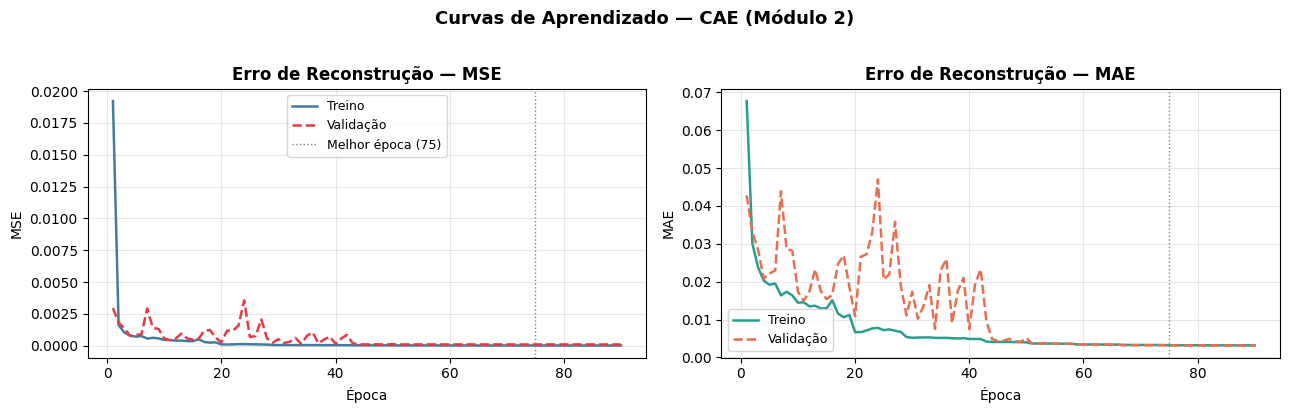

   📈 Curvas salvas: ./2_dados_cae_v2/curvas_treinamento.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 9 — Curvas de aprendizado (loss e MAE)
# ─────────────────────────────────────────────────────────────────────────────

def plotar_curvas_treinamento(historico, output_dir: str) -> None:
    """Plota loss (MSE) e MAE de treino e validação por época."""
    hist = historico.history
    epocas = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # --- MSE ---
    axes[0].plot(epocas, hist['loss'],     color='#457b9d', linewidth=1.8,
                 label='Treino')
    axes[0].plot(epocas, hist['val_loss'], color='#e63946', linewidth=1.8,
                 linestyle='--', label='Validação')
    min_ep = int(np.argmin(hist['val_loss'])) + 1
    axes[0].axvline(min_ep, color='gray', linewidth=1.0, linestyle=':',
                    label=f'Melhor época ({min_ep})')
    axes[0].set_title('Erro de Reconstrução — MSE', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Época', fontsize=10)
    axes[0].set_ylabel('MSE', fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # --- MAE ---
    axes[1].plot(epocas, hist['mae'],     color='#2a9d8f', linewidth=1.8,
                 label='Treino')
    axes[1].plot(epocas, hist['val_mae'], color='#e76f51', linewidth=1.8,
                 linestyle='--', label='Validação')
    axes[1].axvline(min_ep, color='gray', linewidth=1.0, linestyle=':')
    axes[1].set_title('Erro de Reconstrução — MAE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Época', fontsize=10)
    axes[1].set_ylabel('MAE', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Curvas de Aprendizado — CAE (Módulo 2)', fontsize=13,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'curvas_treinamento.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Curvas salvas: {caminho}")


plotar_curvas_treinamento(historico, OUTPUT_DIR)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 10 — Avaliação quantitativa da reconstrução
#
# Métricas usadas (Seção 5.2 do TCC):
#   • RMSE — Root Mean Squared Error (escala p.u.)
#   • MAPE — Mean Absolute Percentage Error (%)
#   • Erro por canal (Va, Vb, Vc) — identifica fases mais perturbadas
# ─────────────────────────────────────────────────────────────────────────────

def avaliar_reconstrucao(cae: Model,
                         X: np.ndarray,
                         output_dir: str) -> pd.DataFrame:
    """
    Reconstrói toda a base, calcula RMSE e MAPE por evento e por fase,
    e retorna um DataFrame com os resultados.
    """
    X_recon = cae.predict(X, batch_size=BATCH_SIZE, verbose=0)

    nomes_fases = ['Va', 'Vb', 'Vc']
    registros = []

    for i in range(X.shape[0]):
        linha = {'evento_idx': i}
        erros_rmse = []
        for c, fase in enumerate(nomes_fases):
            y_true = X[i, :, c]
            y_pred = X_recon[i, :, c]
            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            # MAPE: evitar divisão por zero em amostras próximas de 0
            mask = np.abs(y_true) > 0.01
            mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) /
                                        y_true[mask])) * 100) if mask.any() else np.nan
            linha[f'rmse_{fase}'] = rmse
            linha[f'mape_{fase}'] = mape
            erros_rmse.append(rmse)
        linha['rmse_medio'] = float(np.mean(erros_rmse))
        registros.append(linha)

    df = pd.DataFrame(registros)

    # Sumário
    print("\n📊 Métricas de Reconstrução — Base Completa:")
    print(f"   RMSE médio  (todas as fases) : {df['rmse_medio'].mean():.5f} p.u.")
    print(f"   RMSE máx.   (evento pior)    : {df['rmse_medio'].max():.5f} p.u.")
    for fase in nomes_fases:
        print(f"   RMSE {fase}               : {df[f'rmse_{fase}'].mean():.5f} p.u.  "
              f"| MAPE {fase}: {df[f'mape_{fase}'].mean():.2f} %")

    # Salvar
    path_csv = os.path.join(output_dir, 'metricas_reconstrucao.csv')
    df.to_csv(path_csv, index=False)
    print(f"\n   💾 Métricas salvas: {path_csv}")
    return df, X_recon


df_metricas, X_reconstruido = avaliar_reconstrucao(cae, X_input, OUTPUT_DIR)


📊 Métricas de Reconstrução — Base Completa:
   RMSE médio  (todas as fases) : 0.00383 p.u.
   RMSE máx.   (evento pior)    : 0.33182 p.u.
   RMSE Va               : 0.00381 p.u.  | MAPE Va: 1.08 %
   RMSE Vb               : 0.00389 p.u.  | MAPE Vb: 1.03 %
   RMSE Vc               : 0.00378 p.u.  | MAPE Vc: 1.03 %

   💾 Métricas salvas: ./2_dados_cae_v2/metricas_reconstrucao.csv


/tmp/ipykernel_199782/4029337604.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


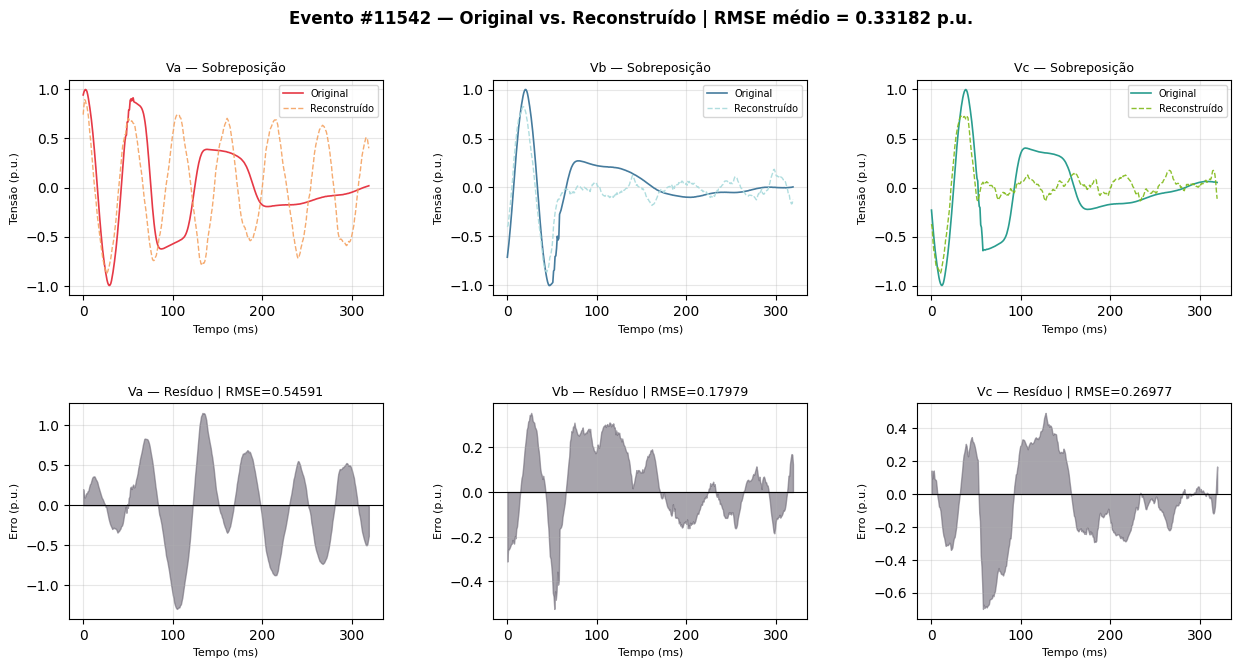

   📈 Salvo: reconstrucao_evento_11542.png


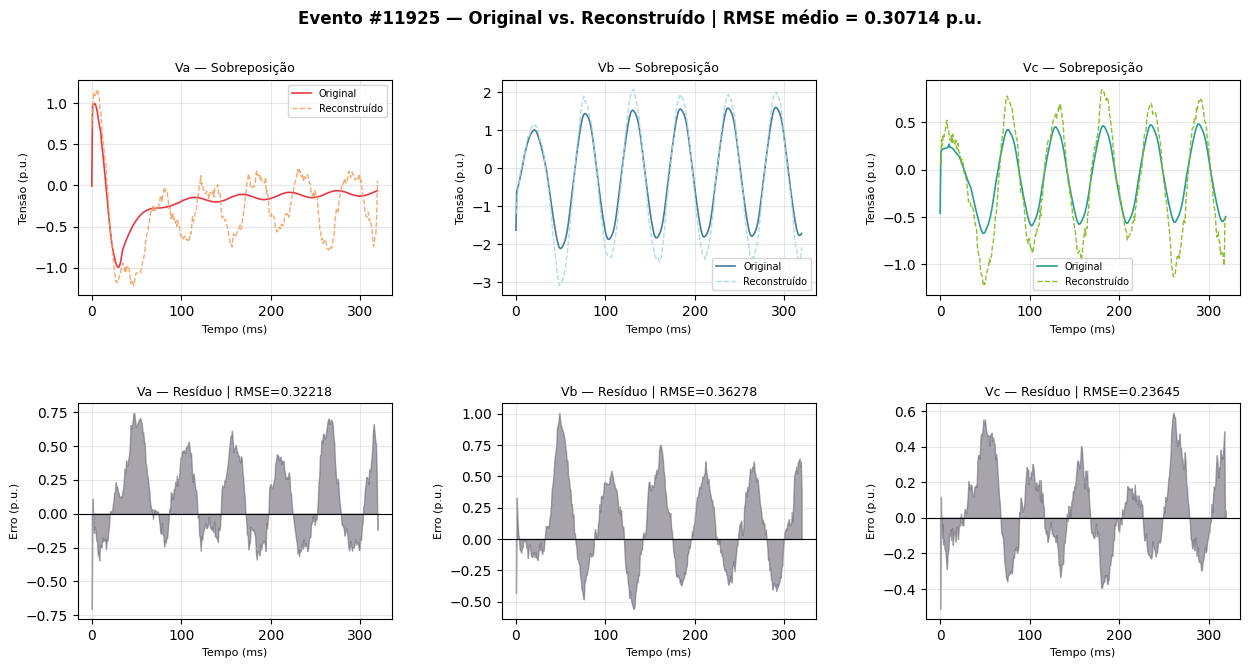

   📈 Salvo: reconstrucao_evento_11925.png


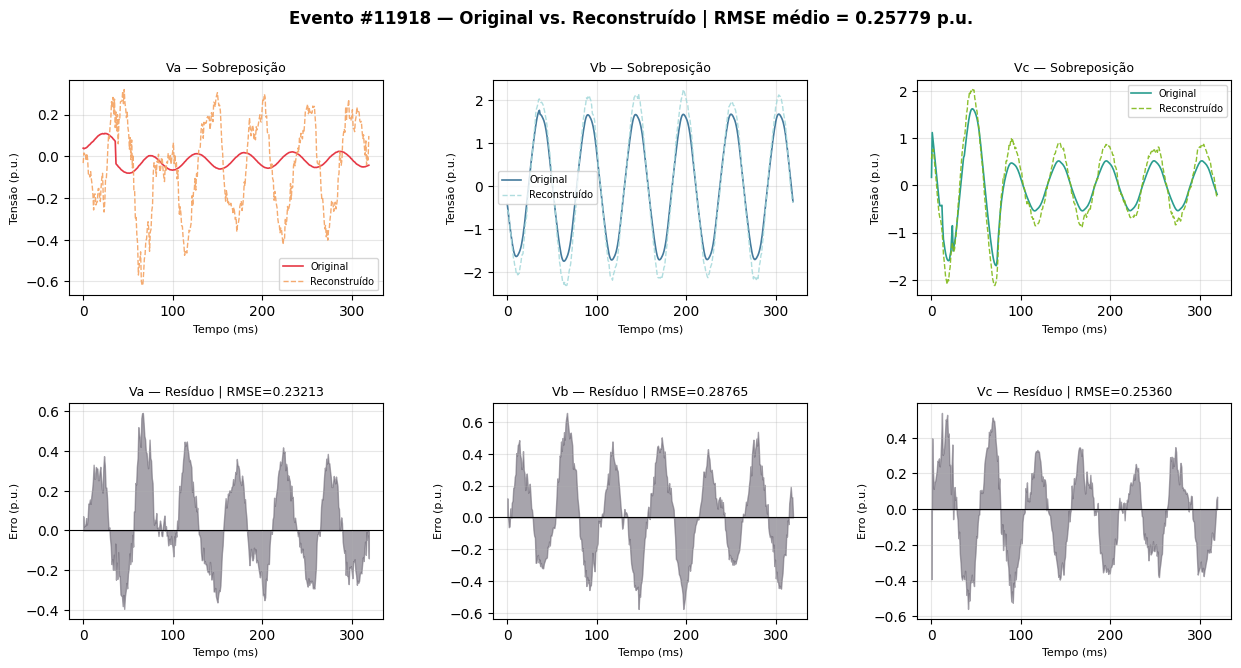

   📈 Salvo: reconstrucao_evento_11918.png


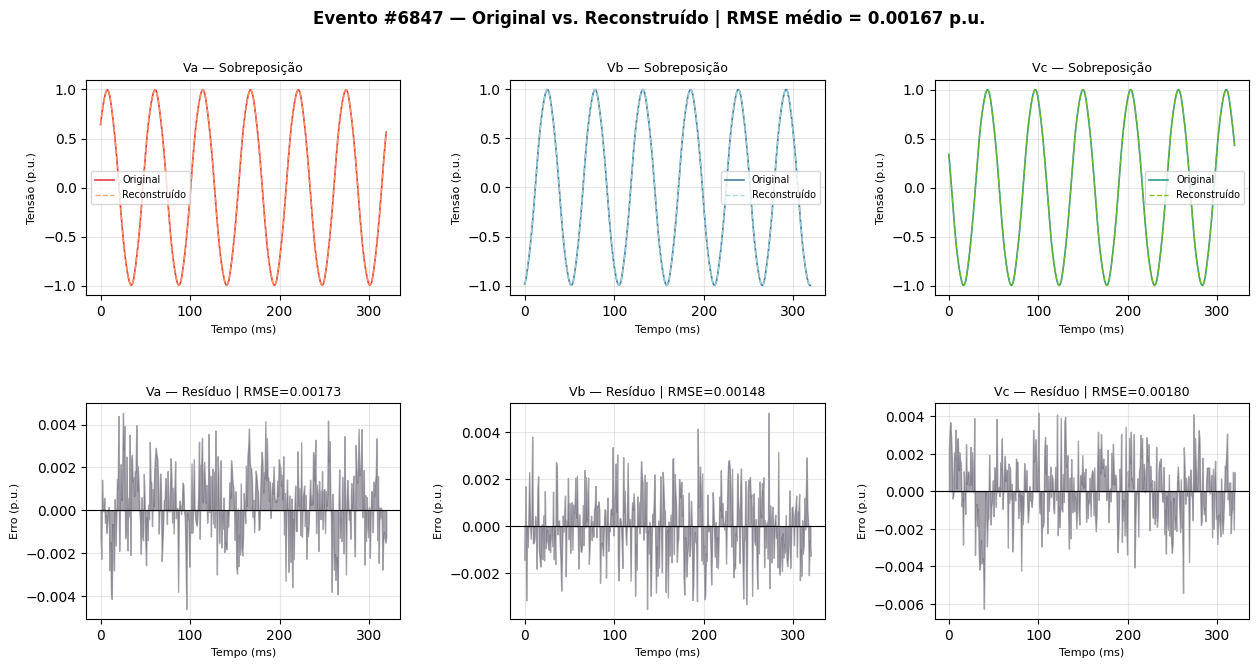

   📈 Salvo: reconstrucao_evento_6847.png


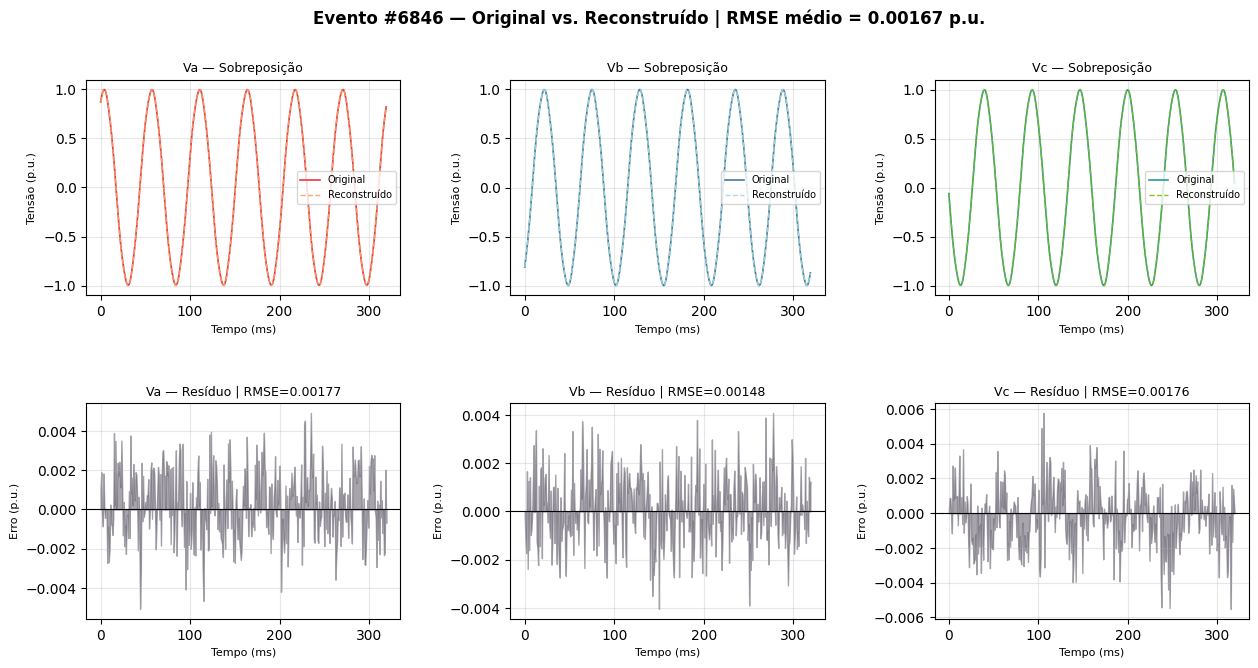

   📈 Salvo: reconstrucao_evento_6846.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 11 — Visualização comparativa: original vs. reconstruído
# ─────────────────────────────────────────────────────────────────────────────

def plotar_reconstrucao(X_orig: np.ndarray,
                        X_recon: np.ndarray,
                        df_metricas: pd.DataFrame,
                        indices: list,
                        output_dir: str,
                        spc: int = 24,
                        freq: float = 50.0) -> None:
    """
    Para cada evento em `indices`, plota sobreposição original vs. reconstruído
    nas 3 fases, mais o resíduo de reconstrução por fase.
    """
    dt   = 1 / (spc * freq)
    t_ms = np.arange(X_orig.shape[1]) * dt * 1e3
    fases  = ['Va', 'Vb', 'Vc']
    cores_orig  = ['#e63946', '#457b9d', '#2a9d8f']
    cores_recon = ['#f4a261', '#a8dadc', '#80b918']

    for idx in indices:
        fig = plt.figure(figsize=(15, 7))
        rmse_med = df_metricas.loc[df_metricas['evento_idx'] == idx, 'rmse_medio'].values
        rmse_str = f"{rmse_med[0]:.5f}" if len(rmse_med) else "N/A"

        fig.suptitle(
            f"Evento #{idx:03d} — Original vs. Reconstruído | RMSE médio = {rmse_str} p.u.",
            fontsize=12, fontweight='bold'
        )
        gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

        for col, (fase, c_orig, c_rec) in enumerate(zip(fases, cores_orig, cores_recon)):
            # Linha 1 — sobreposição
            ax1 = fig.add_subplot(gs[0, col])
            ax1.plot(t_ms, X_orig[idx, :, col],  color=c_orig, lw=1.2,
                     label='Original', zorder=2)
            ax1.plot(t_ms, X_recon[idx, :, col], color=c_rec, lw=1.0,
                     linestyle='--', label='Reconstruído', zorder=3, alpha=0.9)
            ax1.set_title(f'{fase} — Sobreposição', fontsize=9)
            ax1.set_xlabel('Tempo (ms)', fontsize=8)
            ax1.set_ylabel('Tensão (p.u.)', fontsize=8)
            ax1.legend(fontsize=7)
            ax1.grid(True, alpha=0.3)

            # Linha 2 — resíduo
            ax2 = fig.add_subplot(gs[1, col])
            residuo = X_orig[idx, :, col] - X_recon[idx, :, col]
            ax2.fill_between(t_ms, residuo, alpha=0.6, color='#6d6875')
            ax2.axhline(0, color='black', linewidth=0.8)
            rmse_fase = df_metricas.loc[
                df_metricas['evento_idx'] == idx, f'rmse_{fase}'
            ].values
            rmse_f = f"{rmse_fase[0]:.5f}" if len(rmse_fase) else "N/A"
            ax2.set_title(f'{fase} — Resíduo | RMSE={rmse_f}', fontsize=9)
            ax2.set_xlabel('Tempo (ms)', fontsize=8)
            ax2.set_ylabel('Erro (p.u.)', fontsize=8)
            ax2.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        caminho = os.path.join(output_dir, f'reconstrucao_evento_{idx:04d}.png')
        plt.savefig(caminho, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"   📈 Salvo: {Path(caminho).name}")


# Visualizar os 3 piores erros e 2 melhores (diagnóstico)
idxs_piores  = df_metricas.nlargest(3,  'rmse_medio')['evento_idx'].tolist()
idxs_melhores = df_metricas.nsmallest(2, 'rmse_medio')['evento_idx'].tolist()
plotar_reconstrucao(X_input, X_reconstruido, df_metricas,
                    indices=idxs_piores + idxs_melhores,
                    output_dir=OUTPUT_DIR)

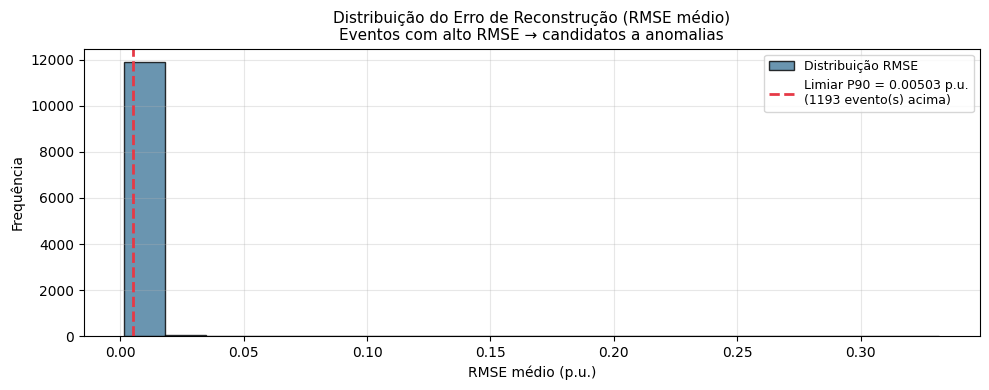

   📈 Histograma salvo: ./2_dados_cae_v2/distribuicao_rmse.png
   ⚠️  1193 evento(s) acima do limiar P90 (0.00503 p.u.) — candidatos a anomalias.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 12 — Distribuição do erro de reconstrução
#
# Eventos com RMSE anormalmente alto são candidatos a anomalias.
# Isso constitui um critério adicional de triagem (Seção 5.2 do TCC).
# ─────────────────────────────────────────────────────────────────────────────

def plotar_distribuicao_rmse(df_metricas: pd.DataFrame,
                              output_dir: str,
                              limiar_percentil: float = 90.0) -> float:
    """
    Plota o histograma do RMSE médio por evento com limiar de anomalia.
    Eventos acima do percentil indicado são sinalizados como anômalos.

    Retorna o valor do limiar calculado.
    """
    rmse = df_metricas['rmse_medio'].values
    limiar = float(np.percentile(rmse, limiar_percentil))
    n_anomalias = int((rmse > limiar).sum())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(rmse, bins=20, color='#457b9d', edgecolor='black',
            alpha=0.8, label='Distribuição RMSE')
    ax.axvline(limiar, color='#e63946', linewidth=2.0, linestyle='--',
               label=f'Limiar P{limiar_percentil:.0f} = {limiar:.5f} p.u.\n'
                     f'({n_anomalias} evento(s) acima)')
    ax.set_title('Distribuição do Erro de Reconstrução (RMSE médio)\n'
                 'Eventos com alto RMSE → candidatos a anomalias', fontsize=11)
    ax.set_xlabel('RMSE médio (p.u.)', fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'distribuicao_rmse.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Histograma salvo: {caminho}")
    print(f"   ⚠️  {n_anomalias} evento(s) acima do limiar P{limiar_percentil:.0f} "
          f"({limiar:.5f} p.u.) — candidatos a anomalias.")
    return limiar


LIMIAR_ANOMALIA = plotar_distribuicao_rmse(df_metricas, OUTPUT_DIR)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 13 — Extração dos vetores latentes (Bottleneck)
#
# Com o CAE treinado, descarta-se o Decoder.
# O Encoder projeta cada evento de 384×3 amostras em um vetor de LATENT_DIM.
# Esses vetores são a ENTRADA do K-Means (Módulo 3 — Seção 4.3.3).
# ─────────────────────────────────────────────────────────────────────────────

def extrair_vetores_latentes(encoder: Model,
                             X: np.ndarray,
                             output_dir: str,
                             latent_path: str) -> np.ndarray:
    """
    Extrai o espaço latente de todos os eventos usando somente o Encoder.

    Parâmetros
    ----------
    encoder    : Model — sub-modelo Encoder treinado
    X          : np.ndarray shape (N, T, C) — dados de entrada normalizados
    output_dir : str   — diretório de saída
    latent_path: str   — caminho .npy para salvar os vetores

    Retorna
    -------
    Z : np.ndarray shape (N, LATENT_DIM) — vetores latentes float32
    """
    Z = encoder.predict(X, batch_size=BATCH_SIZE, verbose=0).astype(np.float32)

    np.save(latent_path, Z)

    print(f"\n✅ Vetores latentes extraídos com sucesso.")
    print(f"   Shape do espaço latente : {Z.shape}  (N_eventos × LATENT_DIM)")
    print(f"   Dtype                   : {Z.dtype}")
    print(f"   Range latente           : [{Z.min():.4f},  {Z.max():.4f}]")
    print(f"   💾 Salvo em: {latent_path}")

    # Estatísticas por dimensão latente
    df_z = pd.DataFrame(Z, columns=[f'z{i:02d}' for i in range(Z.shape[1])])
    print("\n   Estatísticas das dimensões latentes:")
    print(df_z.describe().round(4).to_string())

    return Z


Z_latente = extrair_vetores_latentes(encoder, X_input, OUTPUT_DIR, LATENT_PATH)


✅ Vetores latentes extraídos com sucesso.
   Shape do espaço latente : (11928, 16)  (N_eventos × LATENT_DIM)
   Dtype                   : float32
   Range latente           : [-320.6197,  231.6615]
   💾 Salvo em: ./2_dados_cae_v2/Z_latente.npy

   Estatísticas das dimensões latentes:
              z00         z01         z02         z03         z04         z05         z06         z07         z08         z09         z10         z11         z12         z13         z14         z15
count  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000  11928.0000
mean     -12.3127     -1.8287     -0.2636    -16.8478     -6.0519    -12.9347    -26.5708     -4.4098     -0.5704      0.2882     -8.1561     21.5157     -8.0196      2.9694     -5.7663      2.1111
std       26.1013      6.2665     16.2870     97.8653     85.1014    104.5405     42.3713      8.8373    110.3586     61

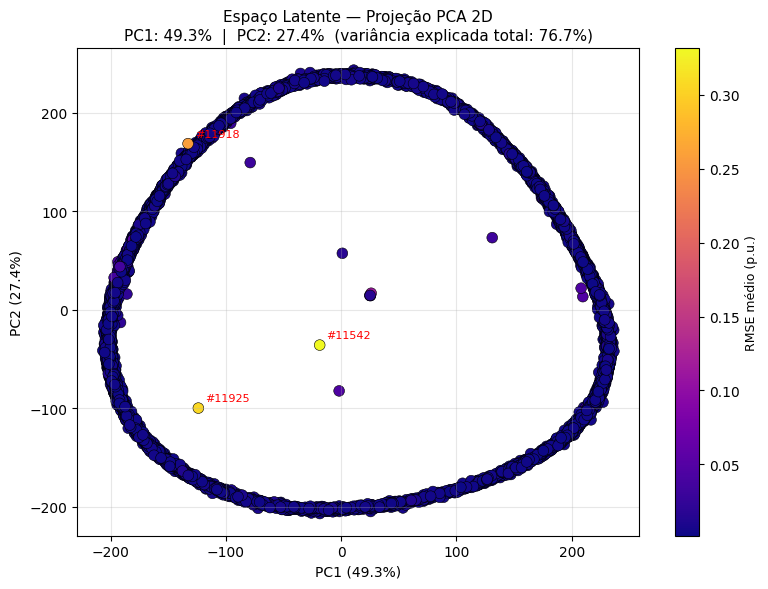

   📈 PCA 2D salvo: ./2_dados_cae_v2/latente_pca2d.png
   Variância explicada: PC1=49.3%  PC2=27.4%


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 14 — Visualização do espaço latente (PCA 2D — diagnóstico)
#
# Projeção PCA do espaço latente para verificar separabilidade visual
# antes do K-Means. O t-SNE completo é aplicado no Módulo 3.
# ─────────────────────────────────────────────────────────────────────────────

def plotar_latente_pca(Z: np.ndarray,
                       df_metricas: pd.DataFrame,
                       output_dir: str) -> None:
    """
    Projeta os vetores latentes em 2D via PCA e coloriza pelo RMSE.
    """
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=42)
    Z_2d = pca.fit_transform(Z)
    var_explicada = pca.explained_variance_ratio_ * 100

    rmse = df_metricas['rmse_medio'].values

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(Z_2d[:, 0], Z_2d[:, 1],
                    c=rmse, cmap='plasma', s=60, edgecolors='black', linewidths=0.4)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('RMSE médio (p.u.)', fontsize=9)

    # Anotar eventos com maior RMSE
    top_idx = df_metricas.nlargest(3, 'rmse_medio')['evento_idx'].tolist()
    for i in top_idx:
        ax.annotate(f'#{i}', (Z_2d[i, 0], Z_2d[i, 1]),
                    fontsize=8, color='red',
                    xytext=(5, 5), textcoords='offset points')

    ax.set_title(
        f'Espaço Latente — Projeção PCA 2D\n'
        f'PC1: {var_explicada[0]:.1f}%  |  PC2: {var_explicada[1]:.1f}%  '
        f'(variância explicada total: {sum(var_explicada):.1f}%)',
        fontsize=11
    )
    ax.set_xlabel(f'PC1 ({var_explicada[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explicada[1]:.1f}%)', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'latente_pca2d.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 PCA 2D salvo: {caminho}")
    print(f"   Variância explicada: PC1={var_explicada[0]:.1f}%  PC2={var_explicada[1]:.1f}%")


plotar_latente_pca(Z_latente, df_metricas, OUTPUT_DIR)

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 15 — Carregar modelo existente (uso em produção / retomar sessão)
#
# Se o CAE já foi treinado e salvo, basta executar esta célula para
# recarregar o modelo e extrair os vetores latentes sem retreinar.
# ─────────────────────────────────────────────────────────────────────────────

def carregar_cae_salvo(model_path: str,
                       encoder_path: str) -> tuple[Model, Model]:
    """
    Recarrega o CAE e o Encoder salvos em disco.

    Uso típico: após encerrar a sessão no Colab, execute esta célula
    para retomar o pipeline sem retreinar.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modelo não encontrado: {model_path}")
    if not os.path.exists(encoder_path):
        raise FileNotFoundError(f"Encoder não encontrado: {encoder_path}")

    cae_carregado     = tf.keras.models.load_model(model_path)
    encoder_carregado = tf.keras.models.load_model(encoder_path)

    print(f"✅ Modelos recarregados:")
    print(f"   CAE     : {model_path}")
    print(f"   Encoder : {encoder_path}")
    return cae_carregado, encoder_carregado


# Descomente para recarregar em vez de retreinar:
# cae, encoder = carregar_cae_salvo(MODEL_PATH, ENCODER_PATH)
# Z_latente    = np.load(LATENT_PATH)
# print(f"Vetores latentes recarregados: {Z_latente.shape}")

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 16 — Resumo final e handoff para o Módulo 3 (K-Means)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("✅  MÓDULO 2 — AUTOENCODER CONVOLUCIONAL (CAE) CONCLUÍDO")
print("=" * 60)
print(f"\n📂 Arquivos gerados em: '{OUTPUT_DIR}/'")
print(f"   ├── cae_model.keras           — modelo CAE completo")
print(f"   ├── encoder_model.keras       — encoder (extrator de features)")
print(f"   ├── Z_latente.npy             — vetores latentes {Z_latente.shape}")
print(f"   ├── metricas_reconstrucao.csv — RMSE e MAPE por evento")
print(f"   ├── curvas_treinamento.png    — loss/MAE treino vs. validação")
print(f"   ├── reconstrucao_evento_*.png — comparações orig. vs. recon.")
print(f"   ├── distribuicao_rmse.png     — histograma RMSE + anomalias")
print(f"   ├── latente_pca2d.png         — projeção PCA do espaço latente")
print(f"   └── log_treinamento.csv       — métricas por época")

print(f"\n📊 Métricas finais:")
print(f"   RMSE médio (base completa) : {df_metricas['rmse_medio'].mean():.5f} p.u.")
print(f"   Épocas de treinamento      : {len(historico.history['loss'])}")
print(f"   Melhor val_loss (MSE)      : {melhor_val_loss:.6f}")
print(f"   Dimensão espaço latente    : {Z_latente.shape[1]}")

print(f"\n➡️   PRÓXIMA ETAPA — Módulo 3: Clusterização K-Means (Seção 4.3.3)")
print(f"    Entrada: Z_latente.npy  shape={Z_latente.shape}")
print("=" * 60)


✅  MÓDULO 2 — AUTOENCODER CONVOLUCIONAL (CAE) CONCLUÍDO

📂 Arquivos gerados em: './2_dados_cae_v2/'
   ├── cae_model.keras           — modelo CAE completo
   ├── encoder_model.keras       — encoder (extrator de features)
   ├── Z_latente.npy             — vetores latentes (11928, 16)
   ├── metricas_reconstrucao.csv — RMSE e MAPE por evento
   ├── curvas_treinamento.png    — loss/MAE treino vs. validação
   ├── reconstrucao_evento_*.png — comparações orig. vs. recon.
   ├── distribuicao_rmse.png     — histograma RMSE + anomalias
   ├── latente_pca2d.png         — projeção PCA do espaço latente
   └── log_treinamento.csv       — métricas por época

📊 Métricas finais:
   RMSE médio (base completa) : 0.00383 p.u.
   Épocas de treinamento      : 90
   Melhor val_loss (MSE)      : 0.000104
   Dimensão espaço latente    : 16

➡️   PRÓXIMA ETAPA — Módulo 3: Clusterização K-Means (Seção 4.3.3)
    Entrada: Z_latente.npy  shape=(11928, 16)
